In [1]:
# Deep Learning Model to Predict View and Like Count from Features

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm import tqdm
import ast
import matplotlib.pyplot as plt

In [2]:
# --- CONFIG ---
DATA_FILE = Path("../data/processed/dataset.csv")
CACHE_PATH = Path("../data/processed/engagement_dataset_cache.npz")
TARGET_COLUMNS = ["viewCount", "likeCount"]

In [3]:
# --- Dataset Class ---
class EngagementDataset(Dataset):
    def __init__(self, dataframe):
        emotion_columns = [
            'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity','desire',
            'disappointment','disapproval','disgust','embarrassment','excitement','fear','gratitude','grief','joy',
            'love','nervousness','optimism','pride','realization','relief','remorse','sadness','surprise','neutral','change_points'
        ]

        if CACHE_PATH.exists():
            cache = np.load(CACHE_PATH)
            self.X_seq = cache['X_seq']
            self.X_static = cache['X_static']
            self.y = cache['y']
            return

        static_features = dataframe.drop(columns=["video_id"] + TARGET_COLUMNS + emotion_columns)
        emotion_sequences = []

        for _, row in dataframe.iterrows():
            emotion_vector = []
            for col in emotion_columns:
                parsed = ast.literal_eval(row[col])
                emotion_vector.append(parsed)  # shape: [n_emotions x 100]
            emotion_vector = np.array(emotion_vector).T  # shape: [100 x n_emotions]
            emotion_sequences.append(emotion_vector)

        self.X_seq = np.array(emotion_sequences).astype(np.float32)  # shape: [N, 100, n_emotions]
        self.X_static = static_features.values.astype(np.float32)
        self.y = np.log1p(dataframe[TARGET_COLUMNS].values.astype(np.float32))  # log1p transform

        np.savez(CACHE_PATH, X_seq=self.X_seq, X_static=self.X_static, y=self.y)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X_seq[idx]),
            torch.tensor(self.X_static[idx]),
            torch.tensor(self.y[idx])
        )

In [4]:
# --- Attention Block ---
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):  # lstm_out: [B, T, H]
        weights = torch.softmax(self.attn(lstm_out), dim=1)  # [B, T, 1]
        weighted = lstm_out * weights  # [B, T, H]
        return weighted.sum(dim=1)  # [B, H]

In [16]:
# --- Quantile Loss ---
def tilted_loss(q, y, f):
    e = y - f
    return torch.mean(torch.max(q * e, (q - 1) * e))

In [ ]:
class EngagementModel(nn.Module):
    def __init__(self, seq_input_dim, static_input_dim, hidden_size, lstm_layers, dropout):
        super().__init__()
        
        self.lstm = nn.LSTM(input_size=seq_input_dim, hidden_size=hidden_size,
                            num_layers=lstm_layers, dropout=dropout, bidirectional=True, batch_first=True)
        self.attention = Attention(hidden_dim=2*hidden_size)
        
        self.seq_fc = nn.Sequential(
            nn.Linear(2*hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.static_fc = nn.Sequential(
            nn.Linear(static_input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.shared_fc = nn.Sequential(
            nn.Linear(2 * hidden_size, hidden_size),
            nn.ReLU()
        )
        
        self.head_views = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        self.head_likes = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_seq, x_static):
        lstm_out, _ = self.lstm(x_seq)
        seq_repr = self.attention(lstm_out)
        seq_out = self.seq_fc(seq_repr)
        static_out = self.static_fc(x_static)
        combined = torch.cat((seq_out, static_out), dim=1)
        shared = self.shared_fc(combined)
        return torch.cat([self.head_views(shared), self.head_likes(shared)], dim=1)

In [6]:
# --- Model Config ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 5e-4
LSTM_LAYERS = 2
HIDDEN_SIZE = 128
DROPOUT = 0.3

In [7]:
# --- Load Data ---
df = pd.read_csv(DATA_FILE)
dataset = EngagementDataset(df)

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

In [8]:
# --- Initialize Model ---
seq_input_dim = dataset.X_seq.shape[2]
static_input_dim = dataset.X_static.shape[1]
model = EngagementModel(seq_input_dim=seq_input_dim, static_input_dim=static_input_dim,
                        hidden_size=HIDDEN_SIZE, lstm_layers=LSTM_LAYERS, dropout=DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.HuberLoss()
mae_criterion = nn.L1Loss()
writer = SummaryWriter(log_dir="../models/runs")

In [9]:
# --- Training Loop ---
train_losses, val_losses, train_maes, val_maes = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_train_loss, epoch_train_mae = [], []
    for xb_seq, xb_static, yb in train_dl:
        xb_seq, xb_static, yb = xb_seq.to(DEVICE), xb_static.to(DEVICE), yb.to(DEVICE)
        pred = model(xb_seq, xb_static)
        loss = criterion(pred, yb)
        mae = mae_criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss.append(loss.item())
        epoch_train_mae.append(mae.item())

    model.eval()
    epoch_val_loss, epoch_val_mae = [], []
    with torch.no_grad():
        for xb_seq, xb_static, yb in val_dl:
            xb_seq, xb_static, yb = xb_seq.to(DEVICE), xb_static.to(DEVICE), yb.to(DEVICE)
            pred = model(xb_seq, xb_static)
            loss = criterion(pred, yb)
            mae = mae_criterion(pred, yb)
            epoch_val_loss.append(loss.item())
            epoch_val_mae.append(mae.item())

    avg_train_loss = np.mean(epoch_train_loss)
    avg_val_loss = np.mean(epoch_val_loss)
    avg_train_mae = np.mean(epoch_train_mae)
    avg_val_mae = np.mean(epoch_val_mae)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_maes.append(avg_train_mae)
    val_maes.append(avg_val_mae)

    writer.add_scalars("Loss", {"Train Huber Loss": avg_train_loss, "Val Huber Loss": avg_val_loss}, epoch)
    writer.add_scalars("MAE", {"Train MAE": avg_train_mae, "Val MAE": avg_val_mae}, epoch)

    print(f"Epoch {epoch}: Train Huber Loss = {avg_train_loss:.4f}, Val Huber Loss = {avg_val_loss:.4f}, Train MAE = {avg_train_mae:.4f}, Val MAE = {avg_val_mae:.4f}")

writer.close()

Epoch 1: Train Huber Loss = 4.4998, Val Huber Loss = 0.5326, Train MAE = 4.9563, Val MAE = 0.7247
Epoch 2: Train Huber Loss = 0.7976, Val Huber Loss = 0.4932, Train MAE = 1.1698, Val MAE = 0.8412
Epoch 3: Train Huber Loss = 0.6520, Val Huber Loss = 0.4862, Train MAE = 0.9948, Val MAE = 0.7193
Epoch 4: Train Huber Loss = 0.5881, Val Huber Loss = 0.4968, Train MAE = 0.9123, Val MAE = 0.7313
Epoch 5: Train Huber Loss = 0.5726, Val Huber Loss = 0.4421, Train MAE = 0.8934, Val MAE = 0.7831
Epoch 6: Train Huber Loss = 0.5601, Val Huber Loss = 0.4118, Train MAE = 0.8828, Val MAE = 0.6982
Epoch 7: Train Huber Loss = 0.5350, Val Huber Loss = 0.4867, Train MAE = 0.8506, Val MAE = 0.9121
Epoch 8: Train Huber Loss = 0.5090, Val Huber Loss = 0.3889, Train MAE = 0.8178, Val MAE = 0.5799
Epoch 9: Train Huber Loss = 0.4878, Val Huber Loss = 0.3801, Train MAE = 0.7923, Val MAE = 0.7316
Epoch 10: Train Huber Loss = 0.4595, Val Huber Loss = 0.3572, Train MAE = 0.7568, Val MAE = 0.6897
Epoch 11: Train Hub

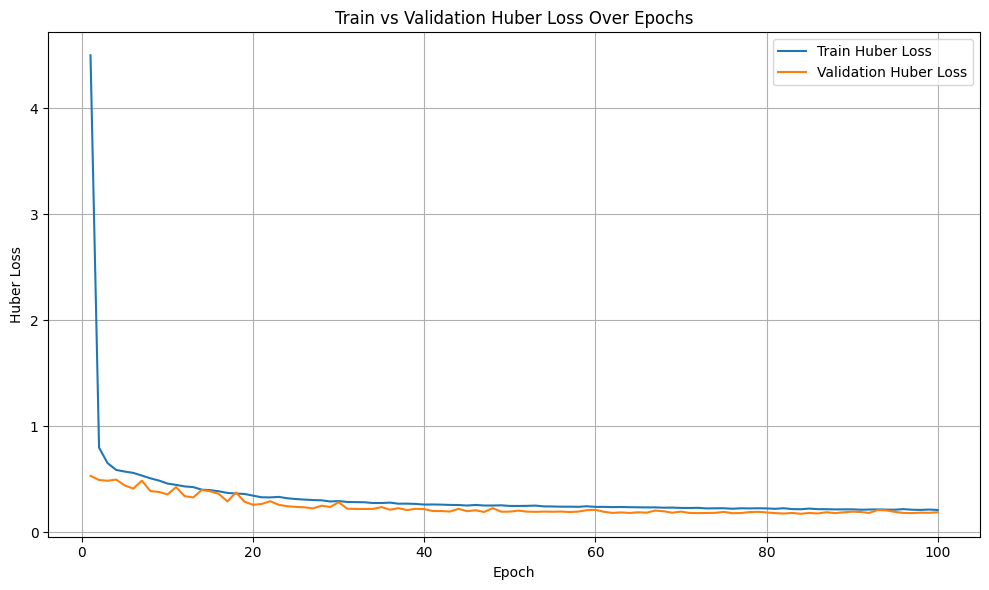

In [13]:
# --- Plot Train vs Validation Loss ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Huber Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Huber Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Train vs Validation Huber Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

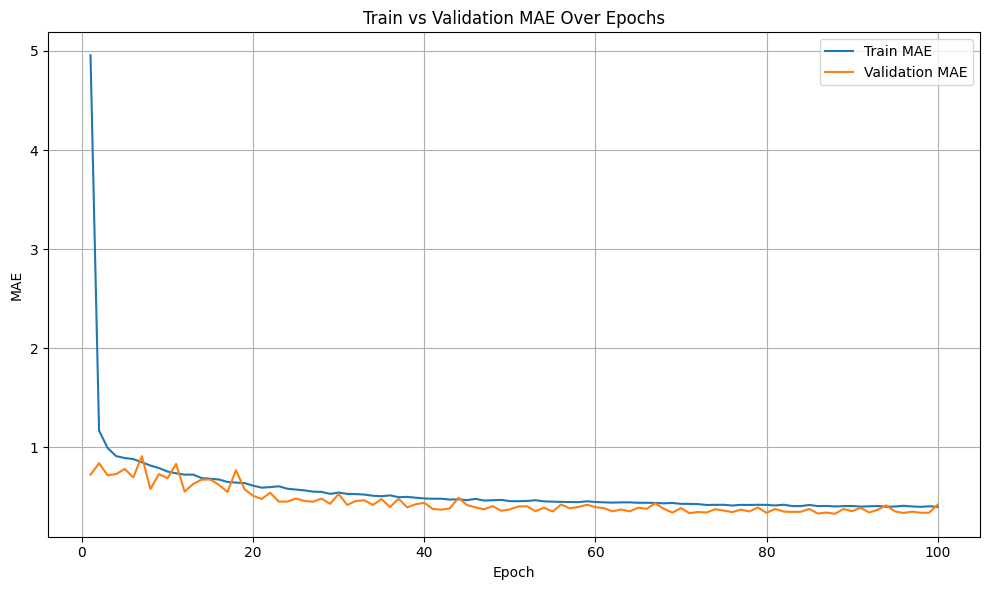

In [14]:
# --- Plot Train vs Validation MAE ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_maes, label='Train MAE')
plt.plot(range(1, EPOCHS + 1), val_maes, label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Train vs Validation MAE Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
import pickle
from random import randint

# --- Inverse Transform and Evaluation on Validation Set ---
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb_seq, xb_static, yb in val_dl:
        xb_seq, xb_static = xb_seq.to(DEVICE), xb_static.to(DEVICE)
        preds = model(xb_seq, xb_static).cpu().numpy()
        targets = yb.cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets)

# Stack and inverse transform
all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Inverse transform using expm1
preds_original = np.expm1(all_preds)
targets_original = np.expm1(all_targets)

with open('../models/target_scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)
    
preds_original = loaded_scaler.inverse_transform(preds_original)
targets_original = loaded_scaler.inverse_transform(targets_original)

# Evaluate metrics in original scale
rmse = np.sqrt(np.mean((preds_original - targets_original) ** 2, axis=0))
mae = np.mean(np.abs(preds_original - targets_original), axis=0)

print("\n--- Inverse Transformed Validation Metrics ---")
print(f"ViewCount  →  RMSE = {rmse[0]:,.2f}  |  MAE = {mae[0]:,.2f}")
print(f"LikeCount  →  RMSE = {rmse[1]:,.2f}  |  MAE = {mae[1]:,.2f}")

# Print a few predictions
print("\nSample Predictions vs Actual:")
for idx in [randint(1, len(preds_original)-1) for _ in range(10)]:
    print(f"Predicted: Views={preds_original[idx][0]:,.0f}, Likes={preds_original[idx][1]:,.0f}  |  Actual: Views={targets_original[idx][0]:,.0f}, Likes={targets_original[idx][1]:,.0f}")



--- Inverse Transformed Validation Metrics ---
ViewCount  →  RMSE = 554,845.12  |  MAE = 91,040.16
LikeCount  →  RMSE = 22,460.82  |  MAE = 2,073.21

Sample Predictions vs Actual:
Predicted: Views=802,138, Likes=14,192  |  Actual: Views=807,353, Likes=23,435
Predicted: Views=1,869, Likes=87  |  Actual: Views=11,096, Likes=313
Predicted: Views=631, Likes=20  |  Actual: Views=4, Likes=1
Predicted: Views=1,009, Likes=40  |  Actual: Views=1,197, Likes=1
Predicted: Views=1,215, Likes=47  |  Actual: Views=90, Likes=1
Predicted: Views=527,653, Likes=17,175  |  Actual: Views=433,583, Likes=8,556
Predicted: Views=496,479, Likes=13,080  |  Actual: Views=943,766, Likes=18,537
Predicted: Views=904, Likes=41  |  Actual: Views=626, Likes=15
Predicted: Views=1,387, Likes=66  |  Actual: Views=27, Likes=4
Predicted: Views=1,011, Likes=37  |  Actual: Views=50, Likes=0
